# Импорт библиотек

In [18]:
# Базовые библиотеки для воспроизводимости, работы с данными и удобного вывода результатов.
import os
import sys
import random
import subprocess
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))


print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)

NumPy: 2.4.3
Pandas: 2.3.3
FAISS available: True


In [19]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cpu


In [20]:
import matplotlib.pyplot as plt

# Сборка базы данных
**Выбранная база знаний:** Кулинария и ресторанное дело

**Почему эта тема:**
- Документы содержат конкретные факты (даты, имена, технологии)
- Позволяет задавать разнообразные фактологические вопросы
- Темы пересекаются, что создаёт интересные кейсы для retrieval
- 12 документов, после чанкинга даёт ~30-50 фрагментов

In [21]:

documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Основные ножи повара и их назначение",
        "text": (
            "У профессионального повара есть несколько основных ножей. Шеф-нож (20-30 см) - универсальный инструмент "
            "для нарезки мяса, рыбы и овощей. Нож сантоку - японский аналог шеф-ножа, отлично подходит для нарезки, "
            "шинковки и рубки. Нож для очистки овощей (пилинг) имеет короткое лезвие 6-10 см для тонкой работы. "
            "Хлебный нож с зазубренным лезвием предназначен для нарезки хлеба и выпечки без крошения. "
            "Нож для разделки мяса имеет гибкое лезвие для отделения мяса от костей. "
            "Ножницы для птицы используются для разделки кур и уток."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Французская кухня: соусы-основы",
        "text": (
            "Французская кулинария выделяет 5 материнских соусов, созданных шеф-поваром Огюстом Эскофье. "
            "Бешамель - белый соус на основе молока, муки и сливочного масла. Используется для лазаньи, мусаки. "
            "Велюте - соус на основе светлого бульона (куриного, телячьего или рыбного) и муки. "
            "Эспаньоль - коричневый соус из говяжьего бульона, темной ру и томатной пасты. "
            "Голландский соус - эмульсия из яичных желтков, сливочного масла и лимонного сока. "
            "Томатный соус - готовится из помидоров, овощей и специй. Из этих соусов создаются производные."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Идеальная паста: правила приготовления",
        "text": (
            "Для идеальной пасты используйте большую кастрюлю: 1 литр воды на 100 г пасты. "
            "Вода должна быть хорошо подсолена (10 г соли на литр) после закипания. "
            "Не ломайте спагетти - они сами размягчатся через 30-40 секунд. "
            "Варите пасту на 1-2 минуты меньше указанного на упаковке времени. "
            "Сохраните 1 стакан воды, в которой варилась паста - она содержит крахмал. "
            "Смешайте пасту с соусом на сковороде, добавив немного крахмальной воды для эмульсии. "
            "Подавайте пасту немедленно в подогретых тарелках."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Темперирование шоколада",
        "text": (
            "Темперирование - процесс нагрева и охлаждения шоколада для получения глянцевой поверхности и хруста. "
            "Для темного шоколада: нагрейте до 45-50°C, охладите до 27°C, затем нагрейте до 31-32°C. "
            "Для молочного шоколада: 40-45°C → 26°C → 29-30°C. Для белого: 40-42°C → 25°C → 28-29°C. "
            "Способы темперирования: мраморная доска (таблирование), микроволновая печь, сувид, "
            "или добавление уже темперированного шоколада (метод посева). "
            "Проверить темперирование можно, нанеся каплю шоколада на пергамент - он должен застыть за 3-5 минут."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Ресторанная сервировка: правила этикета",
        "text": (
            "Стандартная сервировка включает: тарелку для хлеба слева, бокалы справа. "
            "Вилки располагаются слева от основной тарелки: сначала для салата, затем для основного блюда. "
            "Ножи и ложки справа: нож для рыбы, нож для мяса, суповая ложка. "
            "Десертные приборы кладутся над тарелкой. "
            "Бокалы расставляются в порядке использования: для белого вина, красного вина, воды. "
            "Салфетку разворачивают и кладут на колени после того, как сели за стол. "
            "Завершив еду, приборы кладут параллельно на тарелку ручками в правую сторону."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Итальянская пицца: секреты теста",
        "text": (
            "Классическое тесто для неаполитанской пиццы содержит: муку типа '00', воду, соль, свежие дрожжи. "
            "Гидратация теста должна быть 60-65% (600-650 мл воды на 1 кг муки). "
            "После замеса тесто должно отдыхать 24 часа при комнатной температуре. "
            "Растягивайте тесто руками, не используя скалку, чтобы сохранить пузырьки воздуха. "
            "Температура печи для пиццы должна быть 450-500°C, время выпечки - 60-90 секунд. "
            "Классическая пицца Маргарита: томатный соус, моцарелла, свежий базилик, оливковое масло."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Молекулярная кухня: основные техники",
        "text": (
            "Молекулярная гастрономия использует научные принципы приготовления пищи. "
            "Сферификация - превращение жидкости в сферы с помощью альгината натрия и хлорида кальция. "
            "Эмульсификация позволяет создавать устойчивые смеси, например, айр (воздушную пену). "
            "Гелификация с помощью агар-агара превращает жидкости в гели. "
            "Варка при низкой температуре (сувид) сохраняет текстуру и сок продуктов. "
            "Жидкий азот (-196°C) используется для заморозки и создания хрустящей текстуры. "
            "Трансглютаминаза ('мясной клей') соединяет куски белка в одно целое."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Организация ресторанной кухни",
        "text": (
            "Профессиональная кухня разделена на несколько станций. Garde manger отвечает за холодные закуски и салаты. "
            "Station de poisson специализируется на рыбе и морепродуктах. "
            "Station de viande готовит мясные блюда и соусы. "
            "Saucier - мастер соусов, часто самый опытный повар после шефа. "
            "Pâtissier отвечает за десерты и выпечку. "
            "Tournant - повар-универсал, который подменяет отсутствующих. "
            "Система бригад во главе с шеф-поваром была создана Огюстом Эскофье и используется до сих пор."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Виды кофе и способы приготовления",
        "text": (
            "Эспрессо - основа всех кофейных напитков. Готовится под давлением 9 бар. "
            "Американо - эспрессо с горячей водой. Капучино - эспрессо, молоко и молочная пена 1:1:1. "
            "Латте - эспрессо с большим количеством вспененного молока. Латте макиато - молоко с эспрессо. "
            "Ристретто - эспрессо с меньшим количеством воды, более концентрированный. "
            "Альтернативные методы: пуровер (воронка), френч-пресс, аэропресс, хемекс, гейзерная кофеварка. "
            "Турка (джезва) используется для приготовления кофе по-восточному."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Современные пищевые тренды",
        "text": (
            "Растительная кухня (plant-based) набирает популярность: растительное мясо, сыры, молоко. "
            "Безглютеновые и безлактозные опции стали стандартом в ресторанах. "
            "Ферментация возвращается: кимчи, комбуча, квашеные овощи, темпе. "
            "Zero waste - использование всех частей продуктов для минимизации отходов. "
            "Локальные и сезонные продукты предпочитают импортным. "
            "Фуд-технологии: 3D-печать еды, искусственное мясо из клеток, альтернативные белки из насекомых. "
            "Пермакультура и устойчивое сельское хозяйство становятся важными для шеф-поваров."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Хлеб на закваске: искусство пекаря",
        "text": (
            "Закваска - симбиоз молочнокислых бактерий и диких дрожжей. Для её создания нужны мука и вода. "
            "Процесс кормления закваски: удаление части стартера и добавление свежей муки и воды. "
            "Автолиз - смешивание муки и воды без соли для развития клейковины. "
            "Растяжение и складывание (stretch & fold) заменяет интенсивный замес. "
            "Хлеб на закваске требует длительной ферментации (8-24 часа). "
            "Признаки готового хлеба: хрустящая корочка, воздушный мякиш, звук пустоты при постукивании."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Дегустация вина: основные правила",
        "text": (
            "Дегустация вина включает 4 этапа: цвет, аромат, вкус, послевкусие. "
            "Белое вино оценивают при ярком свете на предмет мутности и оттенков. "
            "Красное вино: поднимите бокал, чтобы увидеть цвет от гранатового до рубинового. "
            "Аромат раскрывается после вращения вина в бокале. Первый нос, второй нос. "
            "Во вкусе оценивают: кислотность, танины, алкоголь, сладость, тело вина. "
            "Температура подачи: красное вино - 16-18°C, белое - 8-12°C, игристое - 6-8°C. "
            "Сочетание с едой: белое вино к рыбе, красное к мясу - простое правило, но есть много исключений."
        ),
    },
]

docs_df = pd.DataFrame(documents)
print("Размер корпуса:", len(docs_df))
display(docs_df[["doc_id", "title"]])

Размер корпуса: 12


,doc_id,title
0,doc_01,Основные ножи повара и их назначение
1,doc_02,Французская кухня: соусы-основы
2,doc_03,Идеальная паста: правила приготовления
3,doc_04,Темперирование шоколада
4,doc_05,Ресторанная сервировка: правила этикета
5,doc_06,Итальянская пицца: секреты теста
6,doc_07,Молекулярная кухня: основные техники
7,doc_08,Организация ресторанной кухни
8,doc_09,Виды кофе и способы приготовления
9,doc_10,Современные пищевые тренды


# Чанкинг документов
**Выбранные параметры:**
- `chunk_size = 28` слов (баланс между контекстом и точностью)
- `overlap = 8` слов (чтобы важная мысль не разрывалась на границе)

**Почему такие параметры:**
- 28 слов достаточно для передачи законченной мысли
- Overlap 8 слов (около 30%) обеспечивает плавный переход между чанками
- При таком размере получается оптимальное количество чанков для учебного корпуса

In [22]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)

# Показываем пример чанкинга на одном документе
sample_doc = documents[0]
sample_chunks = chunk_text(sample_doc["text"], chunk_size=28, overlap=8)

print(f"Документ: {sample_doc['title']}")
print(f"Исходный текст: {sample_doc['text'][:150]}...")
print(f"\nКоличество чанков: {len(sample_chunks)}")
print("\nПримеры чанков:")
for i, chunk in enumerate(sample_chunks[:2]):
    print(f"\nЧанк {i+1}:")
    print(f"  {chunk[:150]}...")
    print(f"  Длина: {len(chunk.split())} слов")

# Построение всех чанков
def build_chunks(documents: List[Dict[str, str]], chunk_size: int = 28, overlap: int = 8) -> List[Dict]:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": chunk_idx,
                "chunk_text": chunk_text_value,
            })
    return pd.DataFrame(rows)


chunks_df = build_chunks(documents, chunk_size=28, overlap=8)
print(f"\nВсего чанков: {len(chunks_df)}")
display(chunks_df.head())

Документ: Основные ножи повара и их назначение
Исходный текст: У профессионального повара есть несколько основных ножей. Шеф-нож (20-30 см) - универсальный инструмент для нарезки мяса, рыбы и овощей. Нож сантоку -...

Количество чанков: 4

Примеры чанков:

Чанк 1:
  У профессионального повара есть несколько основных ножей. Шеф-нож (20-30 см) - универсальный инструмент для нарезки мяса, рыбы и овощей. Нож сантоку -...
  Длина: 28 слов

Чанк 2:
  сантоку - японский аналог шеф-ножа, отлично подходит для нарезки, шинковки и рубки. Нож для очистки овощей (пилинг) имеет короткое лезвие 6-10 см для ...
  Длина: 28 слов

Всего чанков: 42


,doc_id,title,chunk_id,chunk_text
0,doc_01,Основные ножи повара и их назначение,0,У профессионального повара есть несколько осно...
1,doc_01,Основные ножи повара и их назначение,1,"сантоку - японский аналог шеф-ножа, отлично по..."
2,doc_01,Основные ножи повара и их назначение,2,6-10 см для тонкой работы. Хлебный нож с зазуб...
3,doc_01,Основные ножи повара и их назначение,3,разделки мяса имеет гибкое лезвие для отделени...
4,doc_02,Французская кухня: соусы-основы,0,Французская кулинария выделяет 5 материнских с...


# Эмбеддинги и индекс FAISS
Выбрать модель, получить векторы, построить FAISS, показать поиск top-k.

**Используемая модель:** sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

**Почему эта модель:**
- Мультиязычная (поддерживает русский язык)
- Компактная (384-мерные векторы)
- Хороший баланс между качеством и скоростью
- Нормализует эмбеддинги, что позволяет использовать скалярное произведение для косинусного сходства

In [23]:
# Единый интерфейс для двух вариантов векторизации: dense embeddings и fallback.
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu", use_mirror: bool = False) -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        import os
        
        if use_mirror:
            os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
            print("Используем зеркало HF: https://hf-mirror.com")
        
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
    use_mirror: bool = True, 
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name=model_name, 
            device=device,
            use_mirror=use_mirror
        )
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE, use_mirror=True)

Используем зеркало HF: https://hf-mirror.com


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5880.71it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


# Векторные представления чанков
Теперь превращаем каждый чанк в вектор. На этом шаге особенно важно следить за двумя вещами:

- форма матрицы: число строк должно совпадать с числом чанков;
- нормировка: для косинусного сходства удобно, когда длина каждого вектора близка к 1.

Если векторы нормализованы, similarity search можно выполнять через обычное скалярное произведение. Это и удобно, и быстро.

In [24]:
# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (42, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


# Индекс FAISS для быстрого поиска
В этом ноутбуке используем:

- FAISS IndexFlatIP, если FAISS доступен;
- NearestNeighbors из sklearn, если нужен fallback.

Снаружи интерфейс будет единым: add(...) и search(...).

In [25]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [26]:
# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)


# Демонстрация поиска на примерных запросах
example_queries = [
    "Как правильно темперировать шоколад для конфет?",
    "Как приготовить идеальное тесто для неаполитанской пиццы?",
    "В чем разница между капучино и латте?",
    "Какие основные ножи нужны профессиональному повару?",
]

for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `Как правильно темперировать шоколад для конфет?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_04,Темперирование шоколада,3,0.7235,каплю шоколада на пергамент - он должен застыт...
1,2,doc_04,Темперирование шоколада,2,0.6314,28-29°C. Способы темперирования: мраморная дос...
2,3,doc_04,Темперирование шоколада,0,0.6140,Темперирование - процесс нагрева и охлаждения ...


### Запрос: `Как приготовить идеальное тесто для неаполитанской пиццы?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_06,Итальянская пицца: секреты теста,2,0.7234,"скалку, чтобы сохранить пузырьки воздуха. Темп..."
1,2,doc_06,Итальянская пицца: секреты теста,0,0.7000,Классическое тесто для неаполитанской пиццы со...
2,3,doc_02,Французская кухня: соусы-основы,0,0.5622,Французская кулинария выделяет 5 материнских с...


### Запрос: `В чем разница между капучино и латте?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_09,Виды кофе и способы приготовления,1,0.5359,молоко и молочная пена 1:1:1. Латте - эспрессо...
1,2,doc_09,Виды кофе и способы приготовления,0,0.4854,Эспрессо - основа всех кофейных напитков. Гото...
2,3,doc_09,Виды кофе и способы приготовления,2,0.4531,"- эспрессо с меньшим количеством воды, более к..."


### Запрос: `Какие основные ножи нужны профессиональному повару?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_01,Основные ножи повара и их назначение,0,0.7358,У профессионального повара есть несколько осно...
1,2,doc_01,Основные ножи повара и их назначение,2,0.6381,6-10 см для тонкой работы. Хлебный нож с зазуб...
2,3,doc_01,Основные ножи повара и их назначение,1,0.5971,"сантоку - японский аналог шеф-ножа, отлично по..."


## Контрольные запросы и оценка retrieval

**Набор контрольных запросов (10 запросов):**

Для оценки качества retrieval подготовлен набор из 10 запросов с указанием ожидаемых релевантных документов.

In [27]:
from dataclasses import dataclass
def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()
@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)

def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [28]:
artifacts = build_retriever(documents, chunk_size=28, overlap=8, device=DEVICE)

benchmark_queries = [
    {"query_id": "q01", "query": "Как правильно темперировать темный шоколад для конфет?", "relevant_doc_ids": ["doc_04"]},
    {"query_id": "q02", "query": "Какие основные соусы используются во французской кулинарии?", "relevant_doc_ids": ["doc_02"]},
    {"query_id": "q03", "query": "Секреты приготовления настоящего итальянского теста для пиццы", "relevant_doc_ids": ["doc_06"]},
    {"query_id": "q04", "query": "Чем отличается капучино от латте и как их готовить?", "relevant_doc_ids": ["doc_09"]},
    {"query_id": "q05", "query": "Какие ножи должен иметь каждый профессиональный повар?", "relevant_doc_ids": ["doc_01"]},
    {"query_id": "q06", "query": "Правила сервировки стола в ресторане высокого уровня", "relevant_doc_ids": ["doc_05"]},
    {"query_id": "q07", "query": "Что такое сферификация и как она применяется в молекулярной кухне?", "relevant_doc_ids": ["doc_07"]},
    {"query_id": "q08", "query": "Как сделать закваску для хлеба в домашних условиях?", "relevant_doc_ids": ["doc_11"]},
    {"query_id": "q09", "query": "Как правильно дегустировать красное и белое вино?", "relevant_doc_ids": ["doc_12"]},
    {"query_id": "q10", "query": "Как устроена профессиональная кухня в ресторане?", "relevant_doc_ids": ["doc_08"]},
    {"query_id": "q11", "query": "Какие тренды в питании популярны в современном мире?", "relevant_doc_ids": ["doc_10"]},
    {"query_id": "q12", "query": "Как сварить пасту аль денте и не переварить её?", "relevant_doc_ids": ["doc_03"]},
]

def evaluate_retrieval(benchmark_queries: List[Dict], artifacts: RetrievalArtifacts, top_k: int = 3) -> pd.DataFrame:
    rows = []
    for item in benchmark_queries:
        results = search_chunks(item["query"], artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = results["doc_id"].tolist()
        relevant = item["relevant_doc_ids"]

        hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant))
        recall = sum(doc_id in predicted_doc_ids for doc_id in relevant) / len(relevant)

        first_relevant_rank = None
        for idx, doc_id in enumerate(predicted_doc_ids, 1):
            if doc_id in relevant:
                first_relevant_rank = idx
                break

        rows.append({
            "query_id": item["query_id"],
            "query": item["query"],
            "expected_source": ", ".join(relevant),
            "retrieved_sources": ", ".join(predicted_doc_ids),
            f"hit@{top_k}": hit,
            f"recall@{top_k}": recall,
            "rank_of_first_relevant": first_relevant_rank,
        })
    return pd.DataFrame(rows)


eval_results = evaluate_retrieval(benchmark_queries, artifacts=artifacts, top_k=3)
display(eval_results)

print("\n=== Сводная статистика ===")
print(f"Средний hit@3: {eval_results['hit@3'].mean():.3f}")
print(f"Средний recall@3: {eval_results['recall@3'].mean():.3f}")

# Сохранение результатов в artifacts
eval_results.to_csv("artifacts/retrieval_eval.csv", index=False)
print("\nРезультаты сохранены в artifacts/retrieval_eval.csv")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5879.71it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,expected_source,retrieved_sources,hit@3,recall@3,rank_of_first_relevant
0,q01,Как правильно темперировать темный шоколад для...,doc_04,"doc_04, doc_04, doc_04",1,1.0,1.0
1,q02,Какие основные соусы используются во французск...,doc_02,"doc_02, doc_02, doc_02",1,1.0,1.0
2,q03,Секреты приготовления настоящего итальянского ...,doc_06,"doc_06, doc_06, doc_02",1,1.0,1.0
3,q04,Чем отличается капучино от латте и как их гото...,doc_09,"doc_07, doc_02, doc_02",0,0.0,NaN
4,q05,Какие ножи должен иметь каждый профессиональны...,doc_01,"doc_01, doc_01, doc_01",1,1.0,1.0
5,q06,Правила сервировки стола в ресторане высокого ...,doc_05,"doc_05, doc_05, doc_05",1,1.0,1.0
6,q07,Что такое сферификация и как она применяется в...,doc_07,"doc_07, doc_10, doc_07",1,1.0,1.0
7,q08,Как сделать закваску для хлеба в домашних усло...,doc_11,"doc_11, doc_05, doc_01",1,1.0,1.0
8,q09,Как правильно дегустировать красное и белое вино?,doc_12,"doc_12, doc_12, doc_12",1,1.0,1.0
9,q10,Как устроена профессиональная кухня в ресторане?,doc_08,"doc_08, doc_08, doc_01",1,1.0,1.0



=== Сводная статистика ===
Средний hit@3: 0.917
Средний recall@3: 0.917

Результаты сохранены в artifacts/retrieval_eval.csv


## Эксперимент с параметрами retrieval

**Цель эксперимента:** Сравнить качество retrieval при разных значениях `top_k` (1, 3, 5).

**Ожидаемый результат:** С ростом `top_k` hit@k и recall@k должны увеличиваться, но MRR может оставаться стабильным.

,top_k,mean_hit,mean_recall,mean_MRR
0,1,0.916667,0.916667,1.000000
1,2,0.916667,0.916667,1.000000
2,3,0.916667,0.916667,1.000000
3,4,0.916667,0.916667,1.000000
4,5,1.000000,1.000000,0.933333


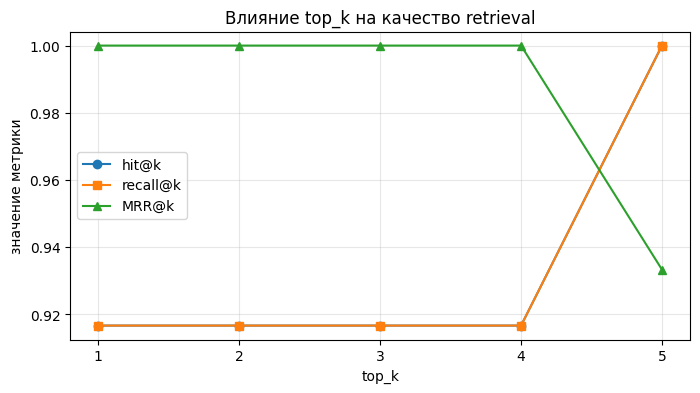

In [29]:
def compute_mrr(results_df: pd.DataFrame) -> float:
    """Вычисляет MRR (Mean Reciprocal Rank) для одного запроса"""
    first_relevant = results_df["rank_of_first_relevant"]
    valid_ranks = first_relevant[first_relevant.notna()]
    if len(valid_ranks) == 0:
        return 0.0
    return (1.0 / valid_ranks).mean()


topk_values = [1, 2, 3, 4, 5]
experiment_results = []

for top_k in topk_values:
    eval_df = evaluate_retrieval(benchmark_queries, artifacts=artifacts, top_k=top_k)
    mrr = compute_mrr(eval_df)

    experiment_results.append({
        "top_k": top_k,
        "mean_hit": eval_df[f"hit@{top_k}"].mean(),
        "mean_recall": eval_df[f"recall@{top_k}"].mean(),
        "mean_MRR": mrr,
    })

exp_df = pd.DataFrame(experiment_results)
display(exp_df)

plt.figure(figsize=(8, 4))
plt.plot(exp_df["top_k"], exp_df["mean_hit"], marker="o", label="hit@k")
plt.plot(exp_df["top_k"], exp_df["mean_recall"], marker="s", label="recall@k")
plt.plot(exp_df["top_k"], exp_df["mean_MRR"], marker="^", label="MRR@k")
plt.xticks([1, 2, 3, 4, 5])  # ← добавить эту строку
plt.xlabel("top_k")
plt.ylabel("значение метрики")
plt.title("Влияние top_k на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

hit@k и recall@k остаются стабильными (0.917) при top_k от 1 до 4, и достигают 1.0 только при top_k=5. Это означает, что для большинства запросов релевантный документ находится на первой позиции, а увеличение top_k до 5 добавляет один "сложный" запрос, который ранее не попадал в top-4.

## Обновление базы знаний и переиндексация

**Цель:** Показать, что без переиндексации новые документы не находятся, а после переиндексации становятся доступны.

In [30]:

new_documents = [
    {
        "doc_id": "doc_13",
        "title": "Приготовление суши и роллов",
        "text": (
            "Для приготовления суши необходимы: специальный рис для суши, рисовый уксус, нори (листы морской водоросли), "
            "свежая рыба (лосось, тунец), огурец, авокадо, соевый соус, васаби и имбирь. "
            "Рис для суши нужно варить особым способом: промыть до прозрачной воды, варить 15 минут, затем "
            "заправить смесью рисового уксуса, сахара и соли. Для приготовления роллов маки: положите нори на бамбуковый коврик, "
            "распределите рис тонким слоем, добавьте начинку и сверните рулет, затем нарежьте на 6-8 кусочков. "
            "Для роллов урамаки (рис снаружи) распределите рис по всей поверхности нори, переверните, "
            "добавьте начинку и сверните. Подавайте суши с соевым соусом, васаби и имбирем."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Технология су-вид (Sous-vide)",
        "text": (
            "Су-вид — это метод приготовления пищи в вакуумном пакете при точно контролируемой низкой температуре. "
            "Продукты помещаются в герметичный пакет, из которого удаляется воздух, а затем готовятся в водяной бане "
            "при температуре от 55°C до 85°C в течение нескольких часов. Преимущества су-вида: "
            "мясо получается идеально прожаренным по всей толщине без пересыхания, овощи сохраняют текстуру и полезные вещества, "
            "вкус и аромат остаются внутри пакета. После приготовления в су-виде продукты обычно дожаривают на сковороде "
            "или гриле для образования хрустящей корочки (майярдовской реакции). "
            "Температура для стейка: rare - 52°C, medium rare - 57°C, medium - 60°C, well done - 65°C."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "Ферментация: кимчи и квашение",
        "text": (
            "Ферментация — это древний метод консервирования продуктов с помощью полезных бактерий. "
            "Кимчи — корейское ферментированное блюдо из пекинской капусты с острыми специями. "
            "Для приготовления кимчи: нарежьте капусту, засолите на 4-6 часов, затем промойте и смешайте с пастой "
            "из чеснока, имбиря, рыбного соуса, перца кочукару и дайкона. Оставьте ферментироваться при комнатной "
            "температуре на 1-5 дней, затем храните в холодильнике. Классическое квашение капусты: нарежьте белокочанную капусту, "
            "натрите морковь, добавьте соль (2-3% от веса капусты), тмин, перец горошком. Оставьте под гнетом на 3-7 дней. "
            "Ферментированные продукты богаты пробиотиками, полезными для пищеварения."
        ),
    },
]

updated_documents = documents + new_documents

# Запросы к новым документам
new_queries = [
    "Как правильно приготовить рис для суши?",
    "Что такое метод су-вид и при какой температуре готовить стейк medium rare?",
    "В чем разница между кимчи и обычной квашеной капустой?",
]

display(pd.DataFrame(new_documents)[["doc_id", "title"]])
display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_13,Приготовление суши и роллов
1,doc_14,Технология су-вид (Sous-vide)
2,doc_15,Ферментация: кимчи и квашение


### Как baseline-база отвечает на новые запросы

**Запрос:** Как правильно приготовить рис для суши?

,rank,score,doc_id,title,chunk_text
0,1,0.509249,doc_03,Идеальная паста: правила приготовления,"соусом на сковороде, добавив немного крахмальн..."
1,2,0.443597,doc_05,Ресторанная сервировка: правила этикета,"за стол. Завершив еду, приборы кладут параллел..."
2,3,0.435116,doc_03,Идеальная паста: правила приготовления,меньше указанного на упаковке времени. Сохрани...


**Запрос:** Что такое метод су-вид и при какой температуре готовить стейк medium rare?

,rank,score,doc_id,title,chunk_text
0,1,0.596073,doc_03,Идеальная паста: правила приготовления,"соусом на сковороде, добавив немного крахмальн..."
1,2,0.527195,doc_04,Темперирование шоколада,"до 27°C, затем нагрейте до 31-32°C. Для молочн..."
2,3,0.514403,doc_04,Темперирование шоколада,28-29°C. Способы темперирования: мраморная дос...


**Запрос:** В чем разница между кимчи и обычной квашеной капустой?

,rank,score,doc_id,title,chunk_text
0,1,0.355999,doc_01,Основные ножи повара и их назначение,"сантоку - японский аналог шеф-ножа, отлично по..."
1,2,0.338801,doc_07,Молекулярная кухня: основные техники,температуре (сувид) сохраняет текстуру и сок п...
2,3,0.326747,doc_02,Французская кухня: соусы-основы,"коричневый соус из говяжьего бульона, темной р..."


In [31]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(updated_documents, chunk_size=28, overlap=8, device=DEVICE)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

# Сохранение сравнения
comparison_rows = []
for query in new_queries:
    before = search_chunks(query, artifacts=artifacts, top_k=3)
    after = search_chunks(query, artifacts=updated_artifacts, top_k=3)
    comparison_rows.append({
        "query": query,
        "before_retrieved_sources": ", ".join(before["doc_id"].tolist()),
        "after_retrieved_sources": ", ".join(after["doc_id"].tolist()),
        "changed": before["doc_id"].tolist() != after["doc_id"].tolist(),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("\nРезультаты сохранены в artifacts/retrieval_before_after_update.csv")
display(comparison_df)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5832.83it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


### Как updated-база отвечает на новые запросы

**Запрос:** Как правильно приготовить рис для суши?

,rank,score,doc_id,title,chunk_text
0,1,0.902334,doc_13,Приготовление суши и роллов,Для приготовления суши необходимы: специальный...
1,2,0.856602,doc_13,Приготовление суши и роллов,"соевый соус, васаби и имбирь. Рис для суши нуж..."
2,3,0.784575,doc_13,Приготовление суши и роллов,"заправить смесью рисового уксуса, сахара и сол..."


...

,rank,score,doc_id,title,chunk_text
0,1,0.750408,doc_14,Технология су-вид (Sous-vide),внутри пакета. После приготовления в су-виде п...
1,2,0.638596,doc_14,Технология су-вид (Sous-vide),су-вида: мясо получается идеально прожаренным ...
2,3,0.631979,doc_14,Технология су-вид (Sous-vide),"которого удаляется воздух, а затем готовятся в..."


**Запрос:** В чем разница между кимчи и обычной квашеной капустой?

,rank,score,doc_id,title,chunk_text
0,1,0.644420,doc_15,Ферментация: кимчи и квашение,Ферментация — это древний метод консервировани...
1,2,0.587564,doc_15,Ферментация: кимчи и квашение,острыми специями. Для приготовления кимчи: нар...
2,3,0.389730,doc_13,Приготовление суши и роллов,"нори, переверните, добавьте начинку и сверните..."



Результаты сохранены в artifacts/retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как правильно приготовить рис для суши?,"doc_03, doc_05, doc_03","doc_13, doc_13, doc_13",True
1,Что такое метод су-вид и при какой температуре...,"doc_03, doc_04, doc_04","doc_14, doc_14, doc_14",True
2,В чем разница между кимчи и обычной квашеной к...,"doc_01, doc_07, doc_02","doc_15, doc_15, doc_13",True


## Mini-RAG

**Архитектура mini-RAG:**
1. Получение запроса пользователя
2. Поиск top-k релевантных чанков
3. Сбор контекста из найденных фрагментов
4. Формирование ответа на основе контекста
5. Возврат ответа вместе с источниками

In [32]:
import re
def split_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def build_context(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n{row['chunk_text']}"
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved


def generate_answer(query: str, context: str, max_sentences: int = 2) -> str:
    """Extractive-генератор ответа на основе контекста"""
    lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in lines if not line.startswith("[Источник:")]

    sentences = []
    for line in content_lines:
        sentences.extend(split_sentences(line))

    sentences = [s for s in sentences if len(s.split()) >= 4]

    if not sentences:
        return "Недостаточно контекста для построения ответа."

    # Простой TF-IDF для выбора наиболее релевантных предложений
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sent_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sent_vecs, axis=1) + 1e-12
    scores = (sent_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected = []
    used = set()

    for idx in ranked_idx:
        sent = sentences[idx]
        if scores[idx] <= 0 or sent.lower() in used:
            continue
        used.add(sent.lower())
        selected.append(sent)
        if len(selected) >= max_sentences:
            break

    if not selected:
        return "В найденном контексте нет достаточно релевантного фрагмента."

    return " ".join(selected)


def mini_rag(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Dict:
    context, retrieved = build_context(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer(query, context, max_sentences=2)

    return {
        "query": query,
        "answer": answer,
        "sources": retrieved[["rank", "score", "doc_id", "title", "chunk_text"]],
    }

In [33]:
# Тестирование mini-RAG
test_queries = [
    "Как правильно темперировать шоколад?",
    "Какие соусы считаются основными во французской кухне?",
    "Как приготовить тесто для настоящей итальянской пиццы?",
    "Чем отличается капучино от латте?",
]

rag_examples = []

for query in test_queries:
    result = mini_rag(query, artifacts=artifacts, top_k=3)
    rag_examples.append({
        "question": result["query"],
        "answer": result["answer"],
        "retrieved_sources": ", ".join(result["sources"]["doc_id"].tolist()),
    })

    display(Markdown(f"### Вопрос: {result['query']}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"])

rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df.to_csv("artifacts/rag_examples.csv", index=False)
print("\nРезультаты сохранены в artifacts/rag_examples.csv")

### Вопрос: Как правильно темперировать шоколад?

**Ответ:** В найденном контексте нет достаточно релевантного фрагмента.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.751081,doc_04,Темперирование шоколада,каплю шоколада на пергамент - он должен застыт...
1,2,0.684641,doc_04,Темперирование шоколада,Темперирование - процесс нагрева и охлаждения ...
2,3,0.644941,doc_04,Темперирование шоколада,28-29°C. Способы темперирования: мраморная дос...


### Вопрос: Какие соусы считаются основными во французской кухне?

...

### Вопрос: Чем отличается капучино от латте?

**Ответ:** Латте макиато - молоко с эспрессо. Латте - эспрессо с большим количеством вспененного молока.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.510607,doc_09,Виды кофе и способы приготовления,молоко и молочная пена 1:1:1. Латте - эспрессо...
1,2,0.497286,doc_07,Молекулярная кухня: основные техники,температуре (сувид) сохраняет текстуру и сок п...
2,3,0.476082,doc_09,Виды кофе и способы приготовления,"- эспрессо с меньшим количеством воды, более к..."



Результаты сохранены в artifacts/rag_examples.csv


## Анализ ошибок

**Цель:** Выявить слабые места mini-RAG и понять причины ошибок.

In [34]:
problem_queries = [
    "сегодня хорошая погода",              # Запрос не по теме
    "как починить автомобиль",             # Запрос не по теме 
    "как приготовить борщ",                # Частично есть 
    "кто написал Войну и мир",             # Нет в базе знаний 
]

for query in problem_queries:
    result = mini_rag(query, artifacts=artifacts, top_k=3)
    rag_examples.append({
        "question": result["query"],
        "answer": result["answer"],
        "retrieved_sources": ", ".join(result["sources"]["doc_id"].tolist()),
    })

    display(Markdown(f"### Вопрос: {result['query']}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"])

    # Анализ
    max_score = result['sources']['score'].max()
    if max_score < 0.3:
        print("Проблема: Низкие scores - запрос не соответствует тематике базы знаний")
    elif result['answer'].startswith("Недостаточно контекста"):
        print("Проблема: Контекст содержит информацию, но генератор не смог извлечь ответ")
    else:
        print("Проблема: Запрос слишком общий или неоднозначный")



### Вопрос: сегодня хорошая погода

**Ответ:** В найденном контексте нет достаточно релевантного фрагмента.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.304975,doc_04,Темперирование шоколада,"до 27°C, затем нагрейте до 31-32°C. Для молочн..."
1,2,0.299384,doc_06,Итальянская пицца: секреты теста,"скалку, чтобы сохранить пузырьки воздуха. Темп..."
2,3,0.216277,doc_12,Дегустация вина: основные правила,"второй нос. Во вкусе оценивают: кислотность, т..."


Проблема: Запрос слишком общий или неоднозначный


...

### Вопрос: кто написал Войну и мир

**Ответ:** В найденном контексте нет достаточно релевантного фрагмента.

**Источники:**

,rank,score,doc_id,title,chunk_text
0,1,0.110134,doc_05,Ресторанная сервировка: правила этикета,основного блюда. Ножи и ложки справа: нож для ...
1,2,0.076301,doc_01,Основные ножи повара и их назначение,6-10 см для тонкой работы. Хлебный нож с зазуб...
2,3,0.075021,doc_08,Организация ресторанной кухни,Pâtissier отвечает за десерты и выпечку. Tourn...


Проблема: Низкие scores - запрос не соответствует тематике базы знаний


## Основные типы ошибок 
1. Запросы вне предметной области → низкие scores, случайные чанки
2. Запросы, требующие синтеза информации из нескольких документов → неполный ответ
3. Запросы с синонимами → могут не найти нужный чанк из-за лексического разрыва
4. Слишком общие запросы → возвращают много тематически близких, но нерелевантных чанков
5. Отсутствие информации в базе → уверенный, но неверный ответ (галлюцинация)
